In [15]:
!pip install matplotlib
!pip install xgboost
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [17]:
x_train = np.load("../../data/x_train_resampled.npy")
y_train = np.load("../../data/y_train_resampled.npy")

x_test = np.load("../../data/x_test.npy")
y_test = np.load("../../data/y_test.npy")

print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape : (454902, 30)
Testing Shape : (56962, 30)


In [18]:
lr_model = LogisticRegression(max_iter=1000)

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)
xgb_model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [19]:
lr_pred = lr_model.predict(x_test)
rf_pred = rf_model.predict(x_test)
xgb_pred = xgb_model.predict(x_test)

In [20]:
def evaluate_model(name, y_true, y_pred):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [21]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974597,0.058862,0.918367,0.110633
1,Random Forest,0.999456,0.860215,0.816327,0.837696
2,XGBoost,0.996893,0.341365,0.867347,0.489914


In [22]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

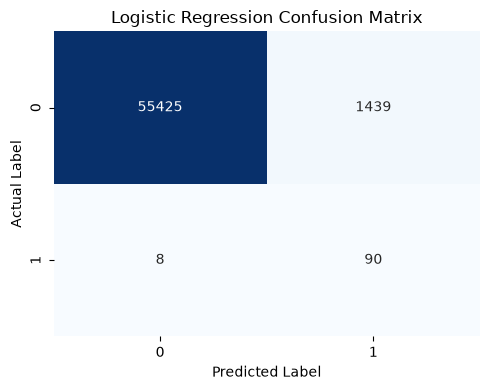

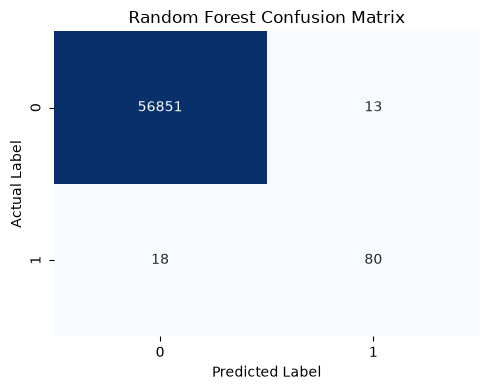

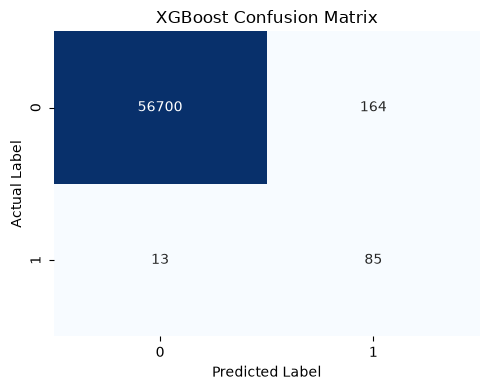

In [23]:
plot_confusion_matrix(
    y_test,
    lr_pred,
    "Logistic Regression Confusion Matrix"
)

plot_confusion_matrix(
    y_test,
    rf_pred,
    "Random Forest Confusion Matrix"
)

plot_confusion_matrix(
    y_test,
    xgb_pred,
    "XGBoost Confusion Matrix"
)

In [24]:
lr_prob = lr_model.predict_proba(x_test)[:,1]

rf_prob = rf_model.predict_proba(x_test)[:,1]

xgb_prob = xgb_model.predict_proba(x_test)[:,1]

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

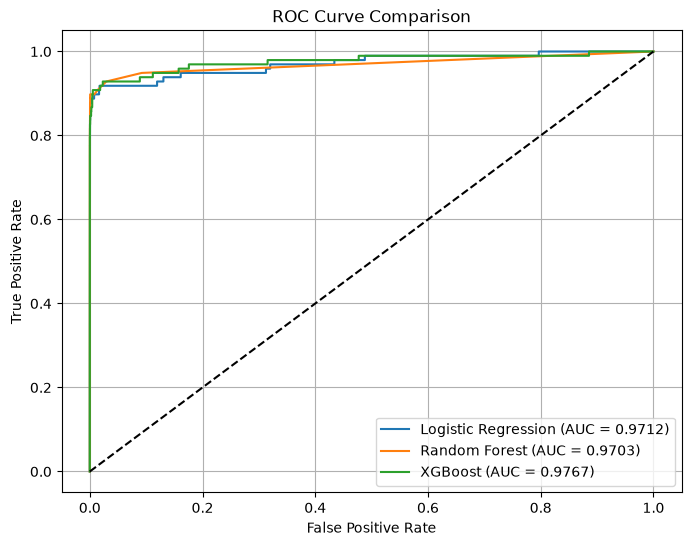

In [26]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f"Logistic Regression (AUC = {lr_auc:.4f})")

plt.plot(rf_fpr, rf_tpr,
         label=f"Random Forest (AUC = {rf_auc:.4f})")

plt.plot(xgb_fpr, xgb_tpr,
         label=f"XGBoost (AUC = {xgb_auc:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

 FINAL RESULTS WITH ROC-AUC:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.974597   0.058862  0.918367  0.110633  0.971206
1        Random Forest  0.999456   0.860215  0.816327  0.837696  0.970302
2              XGBoost  0.996893   0.341365  0.867347  0.489914  0.976714


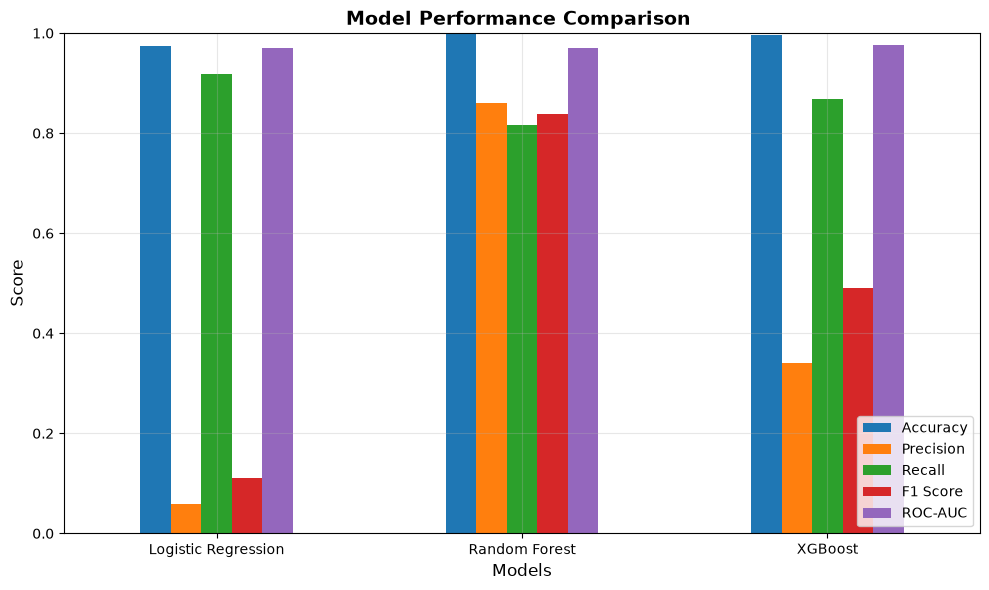

In [27]:
def evaluate_model_with_auc(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results_with_auc = []

results_with_auc.append(
    evaluate_model_with_auc(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_prob  
    )
)

results_with_auc.append(
    evaluate_model_with_auc(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob  
    )
)

results_with_auc.append(
    evaluate_model_with_auc(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob  
    )
)

results_df_final = pd.DataFrame(results_with_auc)

print(" FINAL RESULTS WITH ROC-AUC:")
print(results_df_final)

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

results_df_final.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison ", fontsize=14, fontweight='bold')
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)  
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score


lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_prob)


lr_ap = average_precision_score(y_test, lr_prob)
rf_ap = average_precision_score(y_test, rf_prob)
xgb_ap = average_precision_score(y_test, xgb_prob)

print(f"Logistic Regression Average Precision: {lr_ap:.4f}")
print(f"Random Forest Average Precision: {rf_ap:.4f}")
print(f"XGBoost Average Precision: {xgb_ap:.4f}")


Logistic Regression Average Precision: 0.7251
Random Forest Average Precision: 0.8707
XGBoost Average Precision: 0.8296


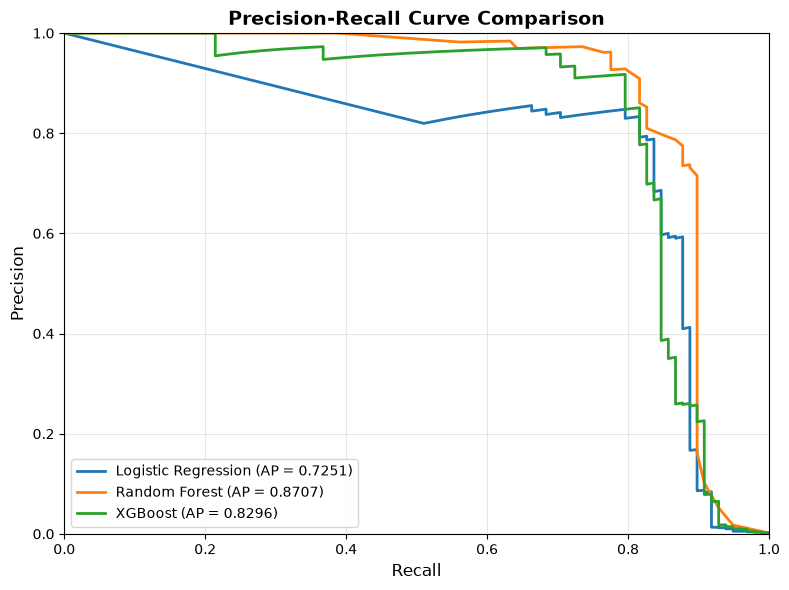

In [29]:
plt.figure(figsize=(8, 6))

plt.plot(lr_recall, lr_precision, 
         label=f'Logistic Regression (AP = {lr_ap:.4f})', linewidth=2)
plt.plot(rf_recall, rf_precision, 
         label=f'Random Forest (AP = {rf_ap:.4f})', linewidth=2)
plt.plot(xgb_recall, xgb_precision, 
         label=f'XGBoost (AP = {xgb_ap:.4f})', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision‑Recall Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:

results_df_final['Average Precision'] = [lr_ap, rf_ap, xgb_ap]
print("\n📊 UPDATED RESULTS WITH PR‑AUC (Average Precision):")
print(results_df_final.round(4))